In [1]:
import QUANTAXIS as QA
from QUANTAXIS.QAData import QA_DataStruct_Stock_block
from QUANTAXIS.QAUtil import  trade_date_sse
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

import DescTools as dt
import seaborn as sns

class Hy:
    def __init__(self):
        self.hy = QA.QA_fetch_stock_block_adv()

def get_hy_list(type='swhy'):
    a = QA.QA_fetch_stock_block_adv().data
    a[a['type']=='swhy'].index.get_level_values('blockname').unique().dropna().tolist()
    

In [118]:
%%time
# dt.get_codes_from_blockname('白酒',sse='all', only_main=True)
# a = QA.QA_fetch_stock_block_adv().data
# a[a['type']=='swhy'].index.get_level_values('blockname').unique().dropna().tolist()
# a.loc[None]
# QA.QA_fetch_stock_block_adv().get_block('白酒').code

a = QA.QA_fetch_stock_block_adv().data
blocks_view = a[a['type'] == 'swhy'].groupby(level=0).apply(
    lambda x:[item for item in x.index.remove_unused_levels().levels[1]]
)


def check_ma_above(hy_codes, end='2021-03-19', gap=60):
    start = trade_date_sse[trade_date_sse.index(end)-gap]
    try:
        data = QA.QA_quotation(hy_codes, start, end, source=QA.DATASOURCE.MONGO,
                           frequence=QA.FREQUENCE.DAY, market=QA.MARKET_TYPE.STOCK_CN,
                           output=QA.OUTPUT_FORMAT.DATASTRUCT)
    except Exception as e:
        print(e)
        return []
    
    close = data.close
    count = len(hy_codes)
    compared = close[19*count:] > close.groupby(level=1).apply(lambda x: QA.MA(x, 20))[19*count:]
    res = compared.groupby(level=0).apply(lambda x: (x.index.get_level_values('date')[0], round(np.sum(x)/len(x),2)))
#     print(res)
#     print(res.sum())
    return res.values

ma_above = blocks_view.apply(check_ma_above)
# print(ma_above)

tmp = ma_above.reset_index()
rebuid_df = pd.DataFrame({'blockname':tmp.blockname.repeat(tmp[0].str.len()),'date':[i[0] for i in np.concatenate(tmp[0].values)],'-':[i[1] for i in np.concatenate(tmp[0].values)]})
pivot = rebuid_df.pivot(index='date', columns='blockname')
print(pivot)



QA Error QA_fetch_stock_day_adv parameter code=['300186'] , start=2020-12-17, end=2021-03-19 call QA_fetch_stock_day return None
'open'
'NoneType' object has no attribute 'set_index'
               -                                                        ...  \
blockname    LED  专业工程  专业连锁  专用汽车   丝绸    中药   乘用车    乳品 互联网信息服务 人工景点  ...   
date                                                                    ...   
2021-01-14   NaN  0.33  0.24  0.50  0.0  0.20   NaN   NaN     NaN  0.0  ...   
2021-01-15  0.12  0.28  0.43  0.50  0.0  0.23   NaN  0.75    0.30  0.0  ...   
2021-01-18  0.33  0.30  0.48  0.75  0.0  0.28  0.50  0.40    0.40  0.0  ...   
2021-01-19  0.50  0.47  0.76  0.50  0.0  0.31  0.14  0.40    0.40  0.0  ...   
2021-01-20  0.39  0.42  0.62  0.50  0.0  0.30  0.14  0.33    0.36  0.0  ...   
2021-01-21  0.39  0.40  0.67  0.50  0.0  0.41  0.29  0.47    0.49  0.0  ...   
2021-01-22  0.11  0.19  0.62  0.00  0.0  0.41  0.14  0.27    0.40  0.0  ...   
2021-01-25  0.33  0.18  0.5

In [120]:
pivot.columns

MultiIndex([('-',     'LED'),
            ('-',    '专业工程'),
            ('-',    '专业连锁'),
            ('-',    '专用汽车'),
            ('-',      '丝绸'),
            ('-',      '中药'),
            ('-',     '乘用车'),
            ('-',      '乳品'),
            ('-', '互联网信息服务'),
            ('-',    '人工景点'),
            ...
            ('-',    '陶瓷制造'),
            ('-',    '集成电路'),
            ('-',  '非金属新材料'),
            ('-',      '鞋帽'),
            ('-',    '食品综合'),
            ('-',      '餐饮'),
            ('-',      '饲料'),
            ('-',    '高速公路'),
            ('-',      '黄酒'),
            ('-',      '黄金')],
           names=[None, 'blockname'], length=202)

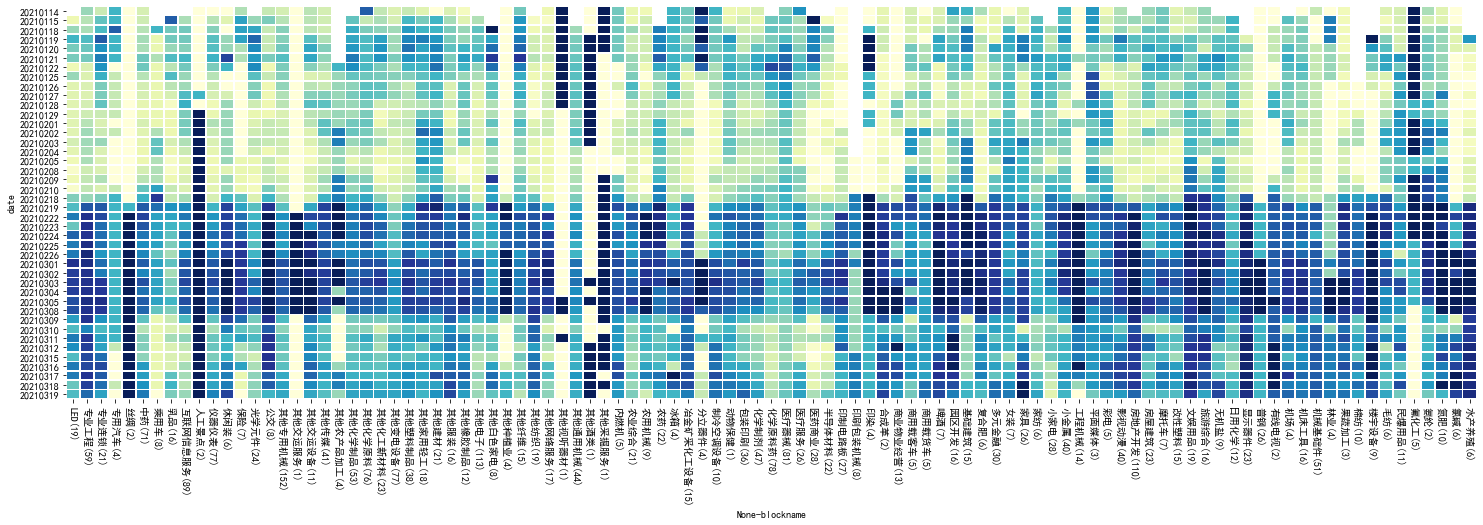

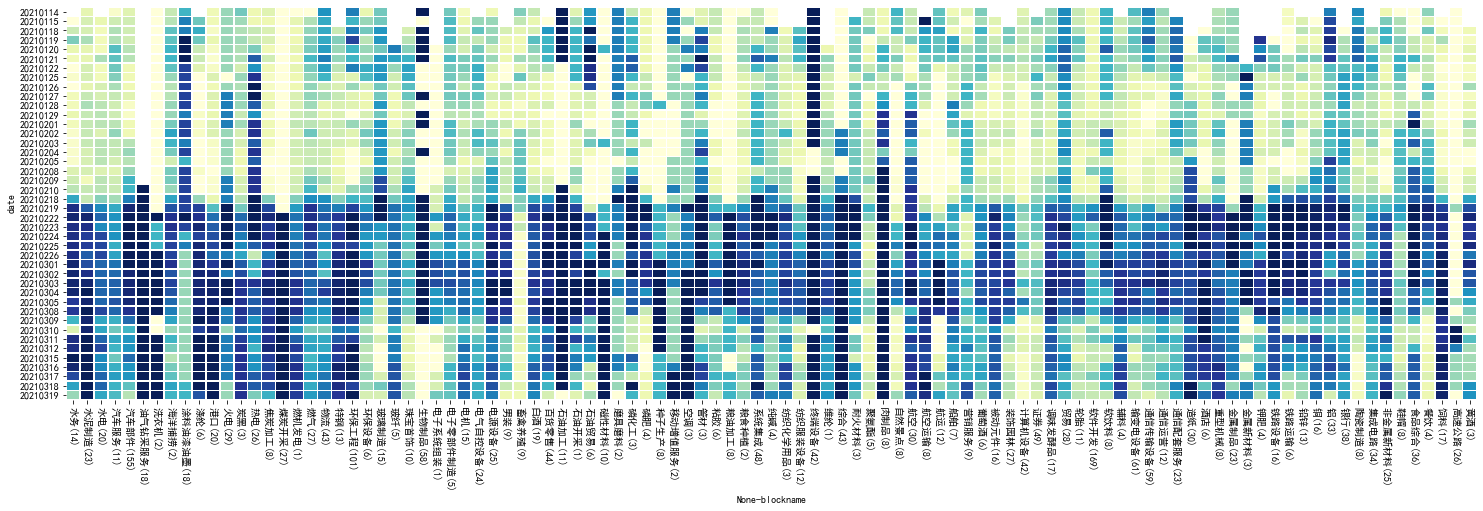

Wall time: 4.64 s


In [131]:
%%time
###### # tmp = ma_above.reset_index()
# df = pd.DataFrame({'blockname':tmp.blockname.repeat(tmp[0].str.len()),'date':[i[0] for i in np.concatenate(tmp[0].values)],'value':[i[1] for i in np.concatenate(tmp[0].values)]})
# df.pivot(index='date', columns='blockname')


# plt.matshow(pivot, cmap=plt.cm.hot, vmin=0, vmax=1)
# plt.colorbar()
# plt.show()

formater = '%Y%m%d' # if self.is_low_frequence else '%Y%m%d %H%M%S'
y_label = [pd.to_datetime(x).strftime(formater) for x in pivot.index.values]
stock_in_block_s = blocks_view.apply(lambda x:len(x))
xlabel = [blockname+'('+str(stock_in_block_s[blockname])+')' for blockname in blocks_view.index.values]

fig = plt.figure(figsize=(1820/72,520/72))
ax = sns.heatmap(pivot.iloc[:,0:101],fmt='.2f', yticklabels=y_label, xticklabels=xlabel[0:101], linewidths=0.5,cbar=False,cmap='YlGnBu')
plt.xticks(rotation = -90)
plt.show()

fig = plt.figure(figsize=(1820/72,520/72))
ax = sns.heatmap(pivot.iloc[:,101:202],fmt='.2f', yticklabels=y_label, xticklabels=xlabel[101:202], linewidths=0.5,cbar=False,cmap='YlGnBu')
plt.xticks(rotation = -90)
plt.show()

